In [121]:
%pip install -Uq pandas scikit-learn nltk pymystem3 matplotlib seaborn scipy

Note: you may need to restart the kernel to use updated packages.


> [!INFO] Для работы потребуется приложенный датасет 'castle-or-lock.tsv'

In [122]:
import pandas as pd

df = pd.read_csv("./aux/castle-or-lock.tsv", sep="\t")
df.head()

,class,text
0,castle,Альксар в Сегвии — замок испанских королей в и...
1,castle,"Замок Бруэм (англ. Brougham /bru()m/[1], иногд..."
2,castle,Верхний замок: 1. Западная башня. 2. Южная баш...
3,castle,Дублинский замок (ирл. Caislen Bhaile tha Clia...
4,castle,Замок Бельмонте (исп. Castillo de Belmonte) — ...


# 1 — Векторизация

#### Предобрабатываем текст лемматизацией

In [123]:
import nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /home/mike-
[nltk_data]     pech/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

#### Кодируем классы

In [124]:
df['class'] = df['class'].map({'castle': 0, 'lock': 1})

In [125]:
from sklearn.feature_extraction.text import CountVectorizer
from pymystem3 import Mystem
from string import punctuation
from nltk.corpus import stopwords

mystem = Mystem()

def preprocess_text(text):
    tokens = mystem.lemmatize(text.lower())
    tokens = [token for token in tokens if token not in stopwords.words("russian")\
              and token != " " \
              and token.strip() not in punctuation]
    
    text = " ".join(tokens)
    
    return text

df['text'] = df['text'].apply(preprocess_text)

df.head()

,class,text
0,0,альксары сегвия — замок испанский король ист...
1,0,"замок бруэм англ brougham bru m /[ 1 ], перед..."
2,0,верхний замок 1 западный башня 2 южный башня 3...
3,0,дублинский замок ирл caislen bhaile tha cliath...
4,0,замок бельмонт исп castillo de belmonte ) — у...


#### Векторизируем

In [126]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["text"])
Y = df['class']
features = vectorizer.get_feature_names_out()

# Выбор признаков

In [127]:
results = {    # Массив для результатов (self-explanatory)
    "Фильтрующие": dict(),
    "Встроенные": dict(),
    "Обёртки": dict(),
}
K_FEAT = 30     # Количество признаков (по условию задачи)

## Библиотечные реализации

### Фильтрующие — взаимная информация

In [128]:
from sklearn.feature_selection import mutual_info_classif
import numpy as np

mi_scores = mutual_info_classif(X, Y, random_state=42)
mi_indices = np.argsort(mi_scores)[::-1][:K_FEAT]
results['Фильтрующие'].update({'mutual_info': {
        'indices': mi_indices,
        'features': features[mi_indices].tolist(),
        'scores': mi_scores[mi_indices]
}})

### Встроенные — случайный лес

In [129]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, Y)
rf_importance = rf.feature_importances_
rf_indices = np.argsort(rf_importance)[::-1][:K_FEAT]
results['Встроенные'].update({'random_forest': {
    'indices': rf_indices,
    'features': features[rf_indices].tolist(),
    'scores': rf_importance[rf_indices]
}})

### Обёртки — Рекурсивное исключение признаков (RFE)

In [130]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
    
# Используем логистическую регрессию как базовый estimator
estimator = LogisticRegression(random_state=88, max_iter=1000)

# RFE выбирает K_FEAT лучших признаков
selector = RFE(estimator, n_features_to_select=K_FEAT, step=0.1)  # step=0.1 - удаляем 10% худших за итерацию
selector = selector.fit(X, Y)

rfe_indices = np.where(selector.support_)[0]

# Чтобы получить scores (ranking признаков)
rfe_ranking = selector.ranking_
# Берем признаки с ranking = 1 (лучшие), затем 2 и т.д.
top_indices = np.argsort(rfe_ranking)[:K_FEAT]

# Оцениваем важность через коэффициенты модели на отобранных признаках
X_selected = X[:, top_indices]
lr = LogisticRegression(random_state=88, max_iter=1000)
lr.fit(X_selected, Y)
coefs = np.abs(lr.coef_[0])

# Сортируем по абсолютным коэффициентам
sorted_within = np.argsort(coefs)[::-1]
final_indices = top_indices[sorted_within]

results['Обёртки'].update({'RFE': {
    'indices': final_indices,
    'features': features[final_indices].tolist(),
    'scores': coefs[sorted_within],
    'ranking': rfe_ranking[final_indices]
}})

## Самодельные реализации

### Фильтрующие — Chi²

In [131]:
def chi2_manual(X, y):
    # Преобразуем X в плотный формат если нужно
    if hasattr(X, 'toarray'):
        X_dense = X.toarray()
    else:
        X_dense = X.copy()
    
    y = np.asarray(y).flatten()
    
    n_samples, n_features = X_dense.shape
    
    chi2_scores = np.zeros(n_features)
    
    # Для каждого признака вычисляем Chi-square
    for feature_idx in range(n_features):
        # Бинаризуем признак (слово есть/нет)
        feature_binary = (X_dense[:, feature_idx] > 0).astype(int)
        
        # Создаем таблицу сопряженности 2x2
        # a: слово есть и класс 0
        # b: слово есть и класс 1
        # c: слова нет и класс 0
        # d: слова нет и класс 1
        
        a = np.sum((feature_binary == 1) & (y == 0))
        b = np.sum((feature_binary == 1) & (y == 1))
        c = np.sum((feature_binary == 0) & (y == 0))
        d = np.sum((feature_binary == 0) & (y == 1))
        
        # Общее количество
        n = a + b + c + d
        
        # Вычисляем Chi-square по упрощенной формуле для 2x2 таблицы
        if n > 0 and (a+b) > 0 and (c+d) > 0 and (a+c) > 0 and (b+d) > 0:
            chi2 = n * (a*d - b*c)**2 / ((a+b)*(c+d)*(a+c)*(b+d))
        else:
            chi2 = 0.0
            
        chi2_scores[feature_idx] = chi2
    
    top_indices = np.argsort(chi2_scores)[::-1][:K_FEAT]
    top_scores = chi2_scores[top_indices]
    
    return top_indices, top_scores

In [132]:
selected_indices, selected_scores = chi2_manual(X, Y)
chi_indices = selected_indices
results['Встроенные'].update({'chi2': {
    'indices': chi_indices,
    'features': features[selected_indices],
    'scores': selected_scores
}})

### Встроенные — Lasso-реегрессия

In [133]:
from scipy import sparse

class LogisticRegressionL1:
    """
    Логистическая регрессия с L1-регуляризацией (для бинарной классификации)
    """
    
    def __init__(self, learning_rate=0.01, iterations=1000, l1_penalty=0.1,
                 tol=1e-4, verbose=False):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.l1_penalty = l1_penalty
        self.tol = tol
        self.verbose = verbose
        self.W = None
        self.b = 0
        
    def _sigmoid(self, z):
        """Сигмоидная функция"""
        # Защита от переполнения
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    def _prepare_X(self, X):
        """Преобразование X в плотный массив"""
        if sparse.issparse(X):
            return X.toarray()
        return X
    
    def _prepare_y(self, y):
        """Преобразование y в numpy array"""
        if isinstance(y, pd.Series):
            return y.values
        elif isinstance(y, pd.DataFrame):
            return y.values.flatten()
        else:
            return np.array(y).flatten()
    
    def fit(self, X, y):
        """Обучение модели"""
        # Преобразуем данные в правильный формат
        X = self._prepare_X(X)
        y = self._prepare_y(y)
        
        # Проверяем, что y бинарный
        unique_y = np.unique(y)
        if len(unique_y) != 2:
            raise ValueError(f"y должен содержать 2 класса, получено: {unique_y}")
        
        # Преобразуем y в 0/1 если нужно
        if set(unique_y) != {0, 1}:
            y_binary = np.where(y == unique_y[0], 0, 1)
        else:
            y_binary = y.copy()
        
        self.m, self.n = X.shape
        self.W = np.zeros(self.n)
        self.b = 0
        
        self.loss_history = []
        
        # Градиентный спуск
        for i in range(self.iterations):
            # Линейная комбинация
            linear_model = X.dot(self.W) + self.b
            # Предсказания (вероятности)
            y_pred = self._sigmoid(linear_model)
            
            # Вычисление потерь (log loss + L1)
            epsilon = 1e-15  # чтобы избежать log(0)
            y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
            
            # Binary cross-entropy loss
            log_loss = -np.mean(y_binary * np.log(y_pred) + (1 - y_binary) * np.log(1 - y_pred))
            l1_loss = self.l1_penalty * np.sum(np.abs(self.W))
            total_loss = log_loss + l1_loss
            self.loss_history.append(total_loss)
            
            # Градиенты
            dw = (1 / self.m) * X.T.dot(y_pred - y_binary)
            db = (1 / self.m) * np.sum(y_pred - y_binary)
            
            # Проксимальный градиентный спуск с L1 (soft-thresholding)
            for j in range(self.n):
                # Проксимальный оператор для L1
                w_j_updated = self.W[j] - self.learning_rate * dw[j]
                
                # Soft thresholding
                threshold = self.learning_rate * self.l1_penalty
                if w_j_updated > threshold:
                    self.W[j] = w_j_updated - threshold
                elif w_j_updated < -threshold:
                    self.W[j] = w_j_updated + threshold
                else:
                    self.W[j] = 0
            
            # Обновление intercept (без регуляризации)
            self.b = self.b - self.learning_rate * db
            
            # Проверка сходимости
            if i > 0 and abs(self.loss_history[-1] - self.loss_history[-2]) < self.tol:
                if self.verbose:
                    print(f"Сходимость достигнута на итерации {i}")
                break
            
            if self.verbose and i % 100 == 0:
                non_zero = np.sum(self.W != 0)
                print(f"Итерация {i:4d}: Loss = {total_loss:.4f}, "
                      f"Ненулевых весов = {non_zero}/{self.n}")
        
        if self.verbose:
            print(f"\nОбучение завершено. Ненулевых признаков: {np.sum(self.W != 0)}")
        
        return self
    
    def predict_proba(self, X):
        """Предсказание вероятностей"""
        X = self._prepare_X(X)
        linear_model = X.dot(self.W) + self.b
        return self._sigmoid(linear_model)
    
    def predict(self, X, threshold=0.5):
        """Предсказание классов"""
        proba = self.predict_proba(X)
        return (proba >= threshold).astype(int)
    
    def get_selected_features(self, threshold=1e-6):
        """Получение отобранных признаков"""
        if self.W is None:
            raise ValueError("Модель не обучена. Сначала вызовите fit().")
        return np.where(np.abs(self.W) > threshold)[0]
    
    def get_feature_importance(self):
        """Важность признаков (абсолютные значения весов)"""
        if self.W is None:
            raise ValueError("Модель не обучена. Сначала вызовите fit().")
        return np.abs(self.W)
    
    def get_coefficients(self):
        """Получить коэффициенты модели"""
        return {'weights': self.W, 'intercept': self.b}

lr_l1 = LogisticRegressionL1(
    learning_rate=0.1,
    iterations=2000,
    l1_penalty=0.5,
    verbose=True
)

lr_l1.fit(X, Y)

selected_indices = lr_l1.get_selected_features(threshold=1e-4)
importance = lr_l1.get_feature_importance()

if len(selected_indices) > 0:
    # Сортируем по важности
    sorted_idx = selected_indices[np.argsort(importance[selected_indices])[::-1]]
    top_idx = sorted_idx[:min(K_FEAT, len(sorted_idx))]
else:
    # Берем топ по важности
    top_idx = np.argsort(importance)[::-1]

Итерация    0: Loss = 0.6931, Ненулевых весов = 19/8605
Итерация  100: Loss = 3.8524, Ненулевых весов = 42/8605
Итерация  200: Loss = 0.9499, Ненулевых весов = 5/8605
Итерация  300: Loss = 1.0390, Ненулевых весов = 5/8605
Итерация  400: Loss = 1.5921, Ненулевых весов = 7/8605
Итерация  500: Loss = 2.5612, Ненулевых весов = 11/8605
Итерация  600: Loss = 4.5394, Ненулевых весов = 39/8605
Итерация  700: Loss = 1.9479, Ненулевых весов = 20/8605
Итерация  800: Loss = 1.2259, Ненулевых весов = 7/8605
Итерация  900: Loss = 1.2450, Ненулевых весов = 6/8605
Итерация 1000: Loss = 2.3923, Ненулевых весов = 11/8605
Итерация 1100: Loss = 0.9483, Ненулевых весов = 6/8605
Итерация 1200: Loss = 1.3220, Ненулевых весов = 7/8605
Итерация 1300: Loss = 2.3932, Ненулевых весов = 12/8605
Итерация 1400: Loss = 0.9366, Ненулевых весов = 5/8605
Итерация 1500: Loss = 2.4909, Ненулевых весов = 12/8605
Итерация 1600: Loss = 2.8073, Ненулевых весов = 15/8605
Итерация 1700: Loss = 0.9337, Ненулевых весов = 5/8605
И

In [134]:
features_array = np.array(features)
top_features = features_array.tolist()

results['Встроенные']['Lasso'] = {
    'features': top_features,
    'scores': importance[top_idx].tolist(),
    'indices': top_idx.tolist(),
    'model': lr_l1
}

### Обёртки — Рекурсивное исключение признаков (RFE)

In [135]:
from sklearn.model_selection import cross_val_score

def recursive_feature_elimination_simple(X, y, estimator, k_features, step=1, cv=5, scoring='accuracy'):
    
    if hasattr(X, 'toarray'):
        X_dense = X.toarray()
    else:
        X_dense = X.copy()
    
    y = np.array(y).flatten()
    n_samples, n_features = X_dense.shape
    
    k_features = min(k_features, n_features)
    
    remaining_indices = list(range(n_features))
    scores_history = []
    
    while len(remaining_indices) > k_features:
        print(f"\nТекущее количество признаков: {len(remaining_indices)}")
        
        # Обучаем модель на текущем наборе признаков
        X_temp = X_dense[:, remaining_indices]
        estimator.fit(X_temp, y)
        
        # Получаем важность признаков
        if hasattr(estimator, 'feature_importances_'):
            importances = estimator.feature_importances_
        elif hasattr(estimator, 'coef_'):
            # Для линейных моделей берем абсолютные значения коэффициентов
            importances = np.abs(estimator.coef_.flatten())
        else:
            # Если нет атрибутов важности, используем кросс-валидацию
            importances = np.zeros(len(remaining_indices))
            for i, idx in enumerate(remaining_indices):
                scores = cross_val_score(
                    estimator, X_dense[:, [idx]], y,
                    cv=min(3, cv), scoring=scoring
                )
                importances[i] = np.mean(scores)
        
        # Определяем сколько признаков удалить на этом шаге
        if isinstance(step, float) and 0 < step < 1:
            n_to_remove = max(1, int(len(remaining_indices) * step))
        else:
            n_to_remove = min(step, len(remaining_indices) - k_features)
        
        # Находим признаки с наименьшей важностью
        worst_indices = np.argsort(importances)[:n_to_remove]
        
        # Удаляем худшие признаки
        # Преобразуем индексы относительно текущего набора в глобальные индексы
        worst_global_indices = [remaining_indices[i] for i in worst_indices]
        for idx in worst_global_indices:
            remaining_indices.remove(idx)
        
        # Оцениваем качество нового набора
        X_temp = X_dense[:, remaining_indices]
        scores = cross_val_score(estimator, X_temp, y, cv=cv, scoring=scoring)
        score_mean = np.mean(scores)
        scores_history.append(score_mean)
        
        print(f"Удалено признаков: {n_to_remove}")
        print(f"Текущий score: {score_mean:.4f}")
        print(f"Худшие признаки: {worst_global_indices}")
    
    print(f"\nОтбор завершен!")
    print(f"Итоговый score: {scores_history[-1]:.4f}")
    print(f"Отобрано признаков: {len(remaining_indices)}")
    
    return np.array(remaining_indices), scores_history

In [136]:
clf = LogisticRegression(random_state=42, max_iter=100)
selected_indices, scores_history = recursive_feature_elimination_simple(X, Y, estimator, K_FEAT, step=0.1, cv=3)

results['Обёртки'].update({'RFE': {
    'features': features[selected_indices],
    'indices': selected_indices,
    'scores': scores_history,
}})


Текущее количество признаков: 8605
Удалено признаков: 860
Текущий score: 0.9762
Худшие признаки: [5640, 7005, 7297, 5519, 8074, 3083, 505, 6639, 498, 2500, 2577, 1028, 379, 3665, 301, 522, 6551, 3823, 4303, 6310, 6434, 6431, 8442, 3732, 3735, 6144, 5434, 3502, 6217, 8012, 4043, 2174, 3249, 226, 7485, 8573, 5794, 6304, 6386, 2794, 440, 2197, 5278, 7274, 1108, 1103, 4836, 5094, 4103, 4098, 6193, 6629, 795, 790, 3927, 2676, 5617, 3443, 806, 783, 6336, 6074, 2909, 2815, 3039, 7044, 7985, 3038, 1048, 2318, 1537, 2724, 857, 855, 7909, 1231, 3629, 2938, 6810, 6819, 7875, 604, 1066, 5462, 478, 4496, 948, 7199, 3276, 578, 573, 5067, 7945, 1288, 7840, 7198, 3828, 7882, 3608, 2545, 6554, 2507, 4219, 3209, 859, 866, 896, 887, 858, 3998, 933, 990, 4374, 8484, 6266, 5051, 7430, 2144, 6288, 2651, 525, 2324, 8102, 2606, 4345, 4344, 6149, 782, 1710, 207, 6559, 1835, 5870, 5100, 4484, 1666, 3366, 8137, 3333, 3342, 7351, 1687, 5650, 169, 5670, 5700, 1122, 5959, 5960, 1149, 8096, 8097, 8098, 4412, 7916, 

## Демонстрация

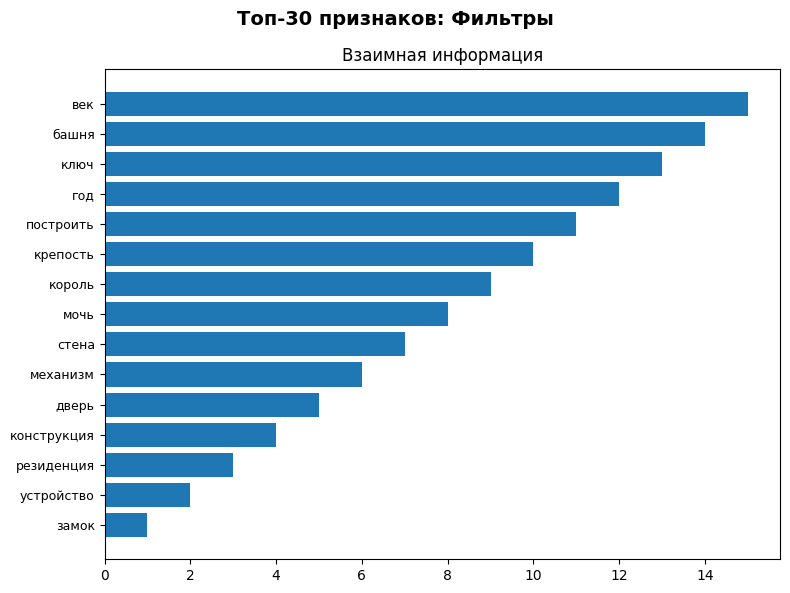

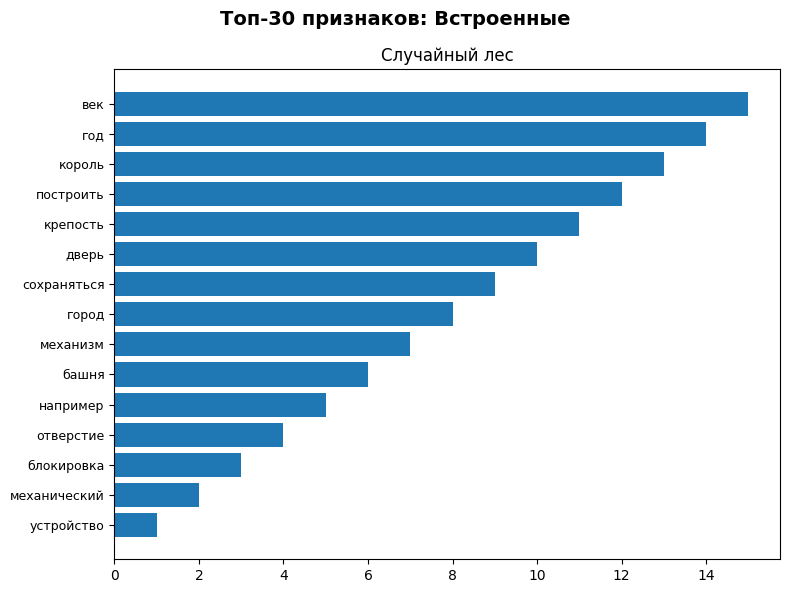

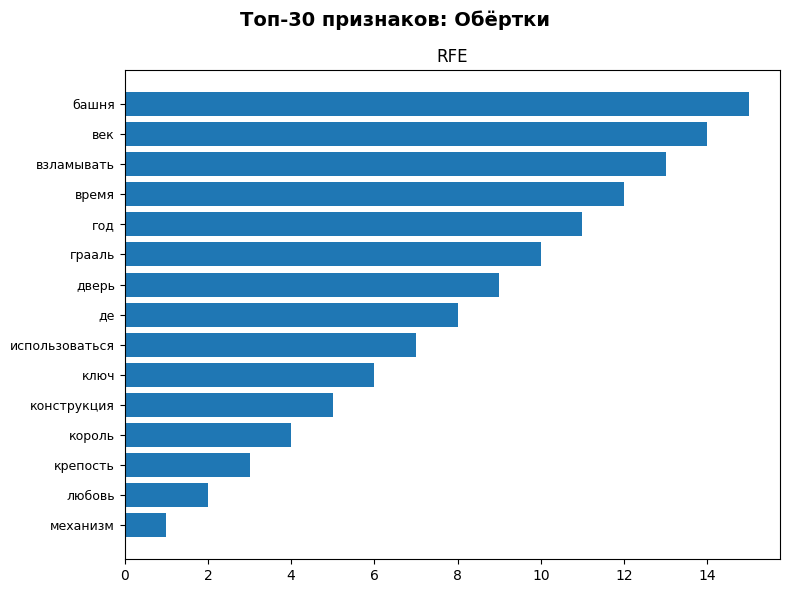

In [137]:
import matplotlib.pyplot as plt

def plot_top_features(method_results_dict, method_name):
    n_subplots = len(method_results_dict)
    
    # Если только один подметод, создаем одну ось
    if n_subplots == 1:
        fig, ax = plt.subplots(figsize=(8, 6))
        axes = [ax]  # Заворачиваем в список для единообразия
    else:
        fig, axes = plt.subplots(1, n_subplots, figsize=(18, 6))

    fig.suptitle(f'Топ-30 признаков: {method_name}', fontsize=14, fontweight='bold')
    
    for idx, (submethod, features) in enumerate(method_results_dict.items()):
        # Для простоты покажем только первые 15 признаков из 30
        top_15 = features[:15]
        axes[idx].barh(range(len(top_15)), range(len(top_15), 0, -1))
        axes[idx].set_yticks(range(len(top_15)))
        axes[idx].set_yticklabels(top_15, fontsize=9)
        axes[idx].set_title(submethod)
        axes[idx].invert_yaxis()
    
    plt.tight_layout()
    plt.show()

feature_results = {
    'Фильтры': {
        'Взаимная информация': results['Фильтрующие']['mutual_info']['features']
    },
    'Встроенные': {
        'Случайный лес': results['Встроенные']['random_forest']['features']
    },
    'Обёртки': {
        'RFE': results['Обёртки']['RFE']['features']
    },
}

# Визуализируем для каждого типа методов
for method_type, submethods in feature_results.items():
    plot_top_features(submethods, method_type)

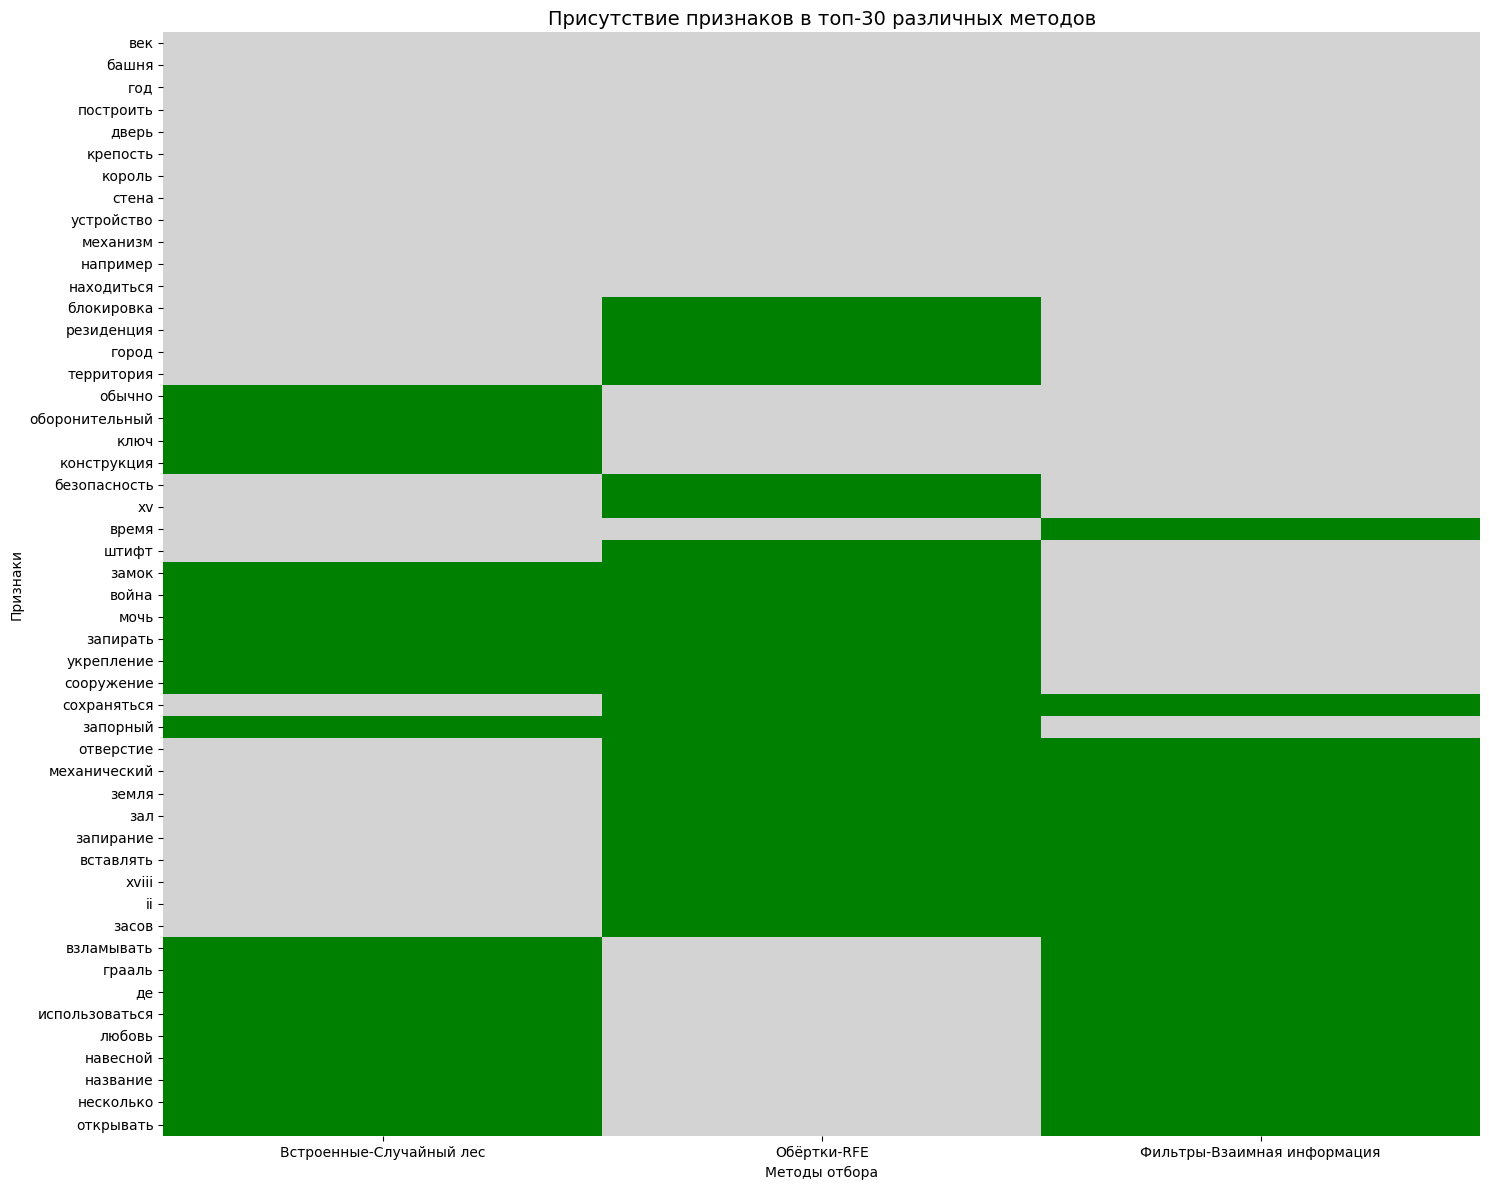

In [138]:
import seaborn as sns

summary_data = []
for method_type, submethods in feature_results.items():
    for submethod, features in submethods.items():
        for rank, feature in enumerate(features[:30], 1):
            summary_data.append({
                'Тип метода': method_type,
                'Конкретный метод': submethod,
                'Место': rank,
                'Признак': feature
            })

summary_df = pd.DataFrame(summary_data)

pivot_table = summary_df.pivot_table(
    index='Признак',
    columns=['Тип метода', 'Конкретный метод'],
    values='Место',
    aggfunc='min'
)

feature_freq = summary_df['Признак'].value_counts()
pivot_table = pivot_table.loc[feature_freq.index[:50]]  # Топ-50 самых частых признаков

plt.figure(figsize=(15, 12))
sns.heatmap(pivot_table.isna(), cbar=False, cmap=['lightgrey', 'green'])
plt.title('Присутствие признаков в топ-30 различных методов', fontsize=14)
plt.ylabel('Признаки')
plt.xlabel('Методы отбора')
plt.tight_layout()
plt.show()

# 2 — Кластеризация

Сравним работу трёх алгоритмов кластеризации до и после выбора признаков — выберем признаки через случайный лес

### До выбора признаков

#### K-means — самодельный

In [139]:
class DIYKMeans:
    
    def __init__(self, n_clusters=2, max_iter=100, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state
        self.centroids = None
        self.labels = None
        self.inertia_history = []
        
        np.random.seed(random_state)
    
    def _initialize_centroids_random(self, X):
        n_samples = X.shape[0]
        indices = np.random.choice(n_samples, self.n_clusters, replace=False)
        return X[indices].copy()
    
    def _euclidean_distance(self, a, b):
        return np.sqrt(np.sum((a - b)**2))
    
    def _assign_clusters(self, X, centroids):
        n_samples = X.shape[0]
        labels = np.zeros(n_samples, dtype=int)
        distances = np.zeros(n_samples)
        
        for i in range(n_samples):
            dist_to_centroids = [self._euclidean_distance(X[i], centroid) 
                               for centroid in centroids]
            labels[i] = np.argmin(dist_to_centroids)
            distances[i] = dist_to_centroids[labels[i]]
        
        return labels, distances
    
    def _update_centroids(self, X, labels):
        n_features = X.shape[1]
        new_centroids = np.zeros((self.n_clusters, n_features))
        
        for k in range(self.n_clusters):
            cluster_points = X[labels == k]
            if len(cluster_points) > 0:
                new_centroids[k] = cluster_points.mean(axis=0)
            else:
                # Если кластер пустой, выбираем случайную точку
                new_centroids[k] = X[np.random.randint(X.shape[0])]
        
        return new_centroids
    
    def fit(self, X):
        n_samples, n_features = X.shape
        
        self.centroids = self._initialize_centroids_random(X)
        
        for iteration in range(self.max_iter):
            labels, distances = self._assign_clusters(X, self.centroids)
            self.labels = labels
            
            inertia = np.sum(distances**2)
            self.inertia_history.append(inertia)
            
            new_centroids = self._update_centroids(X, labels)
            
            centroid_shift = np.mean([self._euclidean_distance(old, new) 
                                    for old, new in zip(self.centroids, new_centroids)])
            
            if iteration % 5 == 0:
                print(f"Итерация {iteration+1:3d}: инерция = {inertia:.2f}, "
                      f"сдвиг центроидов = {centroid_shift:.6f}")
            
            self.centroids = new_centroids
            
            if centroid_shift < 1e-6:
                print(f"\nСходимость достигнута на итерации {iteration+1}")
                break
        
        print(f"\nОбучение завершено. Финальная инерция: {self.inertia_history[-1]:.2f}")
        print(f"Распределение по кластерам:")
        unique, counts = np.unique(self.labels, return_counts=True)
        for label, count in zip(unique, counts):
            print(f"  Кластер {label}: {count} элементом ({count/n_samples*100:.1f}%)")
        
        return self
    
    def predict(self, X):
        labels, _ = self._assign_clusters(X, self.centroids)
        return labels

In [140]:
kmeans = DIYKMeans(n_clusters=2, random_state=19)
X_dense = X.toarray()
kmeans.fit(X_dense)
cluster_labels = kmeans.labels

Итерация   1: инерция = 280127.00, сдвиг центроидов = 37.663197

Сходимость достигнута на итерации 5

Обучение завершено. Финальная инерция: 158194.44
Распределение по кластерам:
  Кластер 0: 7 элементом (8.3%)
  Кластер 1: 77 элементом (91.7%)


> Для наглядности распределения классификации воспользуемся матрицей сопряжения, а также посчитаем полноту (Recall), точность (Precision) и F-меру (support — кол-во экземпляров класса в выборке)

In [141]:
from sklearn.metrics import adjusted_rand_score, confusion_matrix, classification_report

def compare_with_true_labels(cluster_labels, label):
    print(f"\n2. СРАВНЕНИЕ С ИСТИННЫМИ МЕТКАМИ:")
        
        # Adjusted Rand Index
    ari = adjusted_rand_score(Y, cluster_labels)
    print(f"   Adjusted Rand Index: {ari:.4f}")
    if ari > 0.7:
        print("Отличное соответствие истинным классам")
    elif ari > 0.5:
        print("Хорошее соответствие")
    elif ari > 0.3:
        print("Умеренное соответствие")
    else:
        print("Слабое соответствие")

    # Матрица ошибок
    cm = confusion_matrix(Y, cluster_labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Кластер 0', 'Кластер 1'],
                yticklabels=['зАмок', 'замОк'])
    plt.xlabel('Предсказанные кластеры')
    plt.ylabel('Истинные классы')
    plt.title(f'Матрица сопряженности: {label} vs Истинные метки')
    plt.show()

    # Находим оптимальное сопоставление кластеров классам
    from scipy.optimize import linear_sum_assignment

    row_ind, col_ind = linear_sum_assignment(-cm)
    cluster_to_class = {col: row for row, col in zip(row_ind, col_ind)}

    print(f"\n   Оптимальное сопоставление:")
    for cluster, true_class in cluster_to_class.items():
        class_name = 'зАмок (крепость)' if true_class == 0 else 'замОк (механизм)'
        print(f"   Кластер {cluster} → {class_name}")

    # Переименовываем метки и считаем accuracy
    mapped_labels = np.array([cluster_to_class[label] for label in cluster_labels])
    accuracy = np.mean(mapped_labels == Y)

    print(f"\n   Accuracy (после сопоставления): {accuracy:.4f}")

    # Подробный отчет
    print(f"\n   Отчет о классификации:")
    print(classification_report(Y, mapped_labels, 
                                target_names=['зАмок (крепость)', 'замОк (механизм)']))


2. СРАВНЕНИЕ С ИСТИННЫМИ МЕТКАМИ:
   Adjusted Rand Index: 0.0105
Слабое соответствие


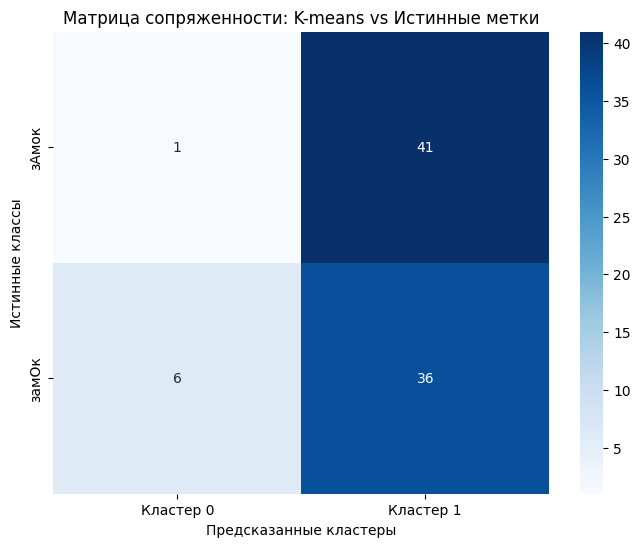


   Оптимальное сопоставление:
   Кластер 1 → зАмок (крепость)
   Кластер 0 → замОк (механизм)

   Accuracy (после сопоставления): 0.5595

   Отчет о классификации:
                  precision    recall  f1-score   support

зАмок (крепость)       0.53      0.98      0.69        42
замОк (механизм)       0.86      0.14      0.24        42

        accuracy                           0.56        84
       macro avg       0.69      0.56      0.47        84
    weighted avg       0.69      0.56      0.47        84



In [142]:
compare_with_true_labels(cluster_labels=cluster_labels, label="K-means")

#### BIRCH

[1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 0 0]

2. СРАВНЕНИЕ С ИСТИННЫМИ МЕТКАМИ:
   Adjusted Rand Index: 0.0105
Слабое соответствие


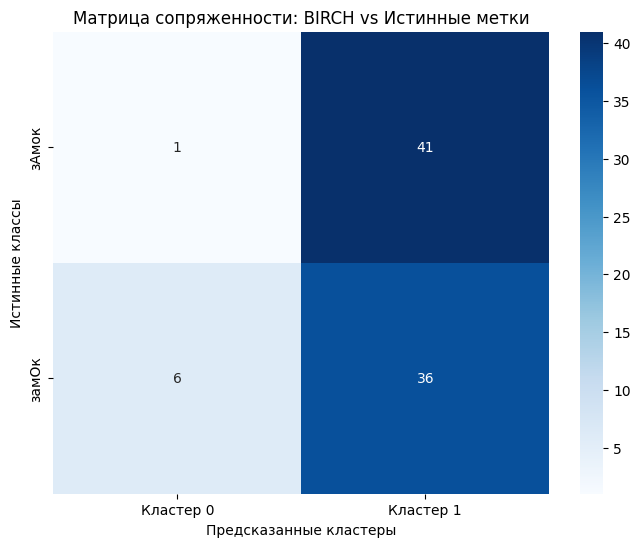


   Оптимальное сопоставление:
   Кластер 1 → зАмок (крепость)
   Кластер 0 → замОк (механизм)

   Accuracy (после сопоставления): 0.5595

   Отчет о классификации:
                  precision    recall  f1-score   support

зАмок (крепость)       0.53      0.98      0.69        42
замОк (механизм)       0.86      0.14      0.24        42

        accuracy                           0.56        84
       macro avg       0.69      0.56      0.47        84
    weighted avg       0.69      0.56      0.47        84



In [143]:
from sklearn.cluster import Birch
brc = Birch(n_clusters=2)
brc.fit(X_dense)
cluster_labels = brc.predict(X_dense)
print(cluster_labels)

compare_with_true_labels(cluster_labels=cluster_labels, label="BIRCH")

#### Спектральная кластеризация


2. СРАВНЕНИЕ С ИСТИННЫМИ МЕТКАМИ:
   Adjusted Rand Index: 0.1536
Слабое соответствие


/home/mike-pech/Documents/masters-theory/ML/Practice/.venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


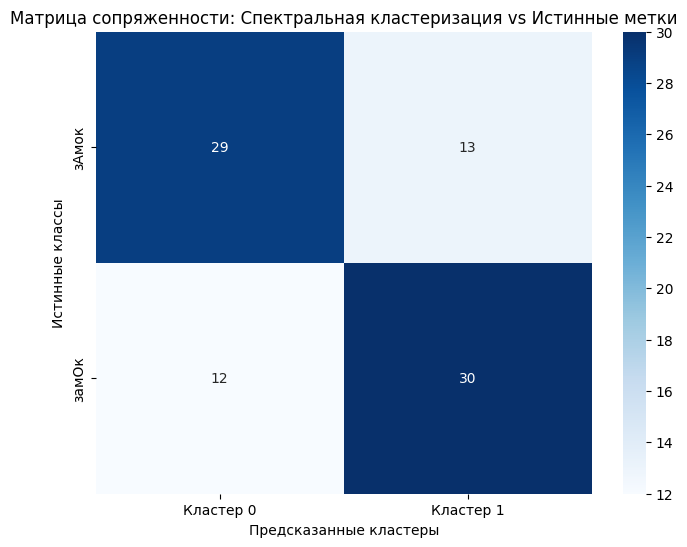


   Оптимальное сопоставление:
   Кластер 0 → зАмок (крепость)
   Кластер 1 → замОк (механизм)

   Accuracy (после сопоставления): 0.7024

   Отчет о классификации:
                  precision    recall  f1-score   support

зАмок (крепость)       0.71      0.69      0.70        42
замОк (механизм)       0.70      0.71      0.71        42

        accuracy                           0.70        84
       macro avg       0.70      0.70      0.70        84
    weighted avg       0.70      0.70      0.70        84



In [144]:
from sklearn.cluster import SpectralClustering

clustering = SpectralClustering(n_clusters=2,
        assign_labels='discretize',
        random_state=0).fit(X_dense)

compare_with_true_labels(cluster_labels=clustering.labels_, label="Спектральная кластеризация")

### Выберем признаки случайным лесом

In [145]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, Y)
rf_importance = rf.feature_importances_
rf_indices = np.argsort(rf_importance)[::-1][:K_FEAT]

Фильтры
Взаимная информация
Итерация   1: инерция = 280127.00, сдвиг центроидов = 37.663197

Сходимость достигнута на итерации 5

Обучение завершено. Финальная инерция: 158194.44
Распределение по кластерам:
  Кластер 0: 7 элементом (8.3%)
  Кластер 1: 77 элементом (91.7%)

2. СРАВНЕНИЕ С ИСТИННЫМИ МЕТКАМИ:
   Adjusted Rand Index: 0.0105
Слабое соответствие


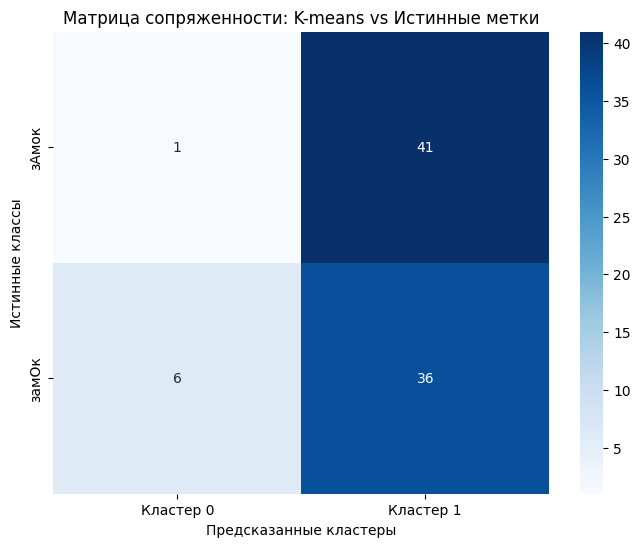


   Оптимальное сопоставление:
   Кластер 1 → зАмок (крепость)
   Кластер 0 → замОк (механизм)

   Accuracy (после сопоставления): 0.5595

   Отчет о классификации:
                  precision    recall  f1-score   support

зАмок (крепость)       0.53      0.98      0.69        42
замОк (механизм)       0.86      0.14      0.24        42

        accuracy                           0.56        84
       macro avg       0.69      0.56      0.47        84
    weighted avg       0.69      0.56      0.47        84


2. СРАВНЕНИЕ С ИСТИННЫМИ МЕТКАМИ:
   Adjusted Rand Index: 0.1536
Слабое соответствие


/home/mike-pech/Documents/masters-theory/ML/Practice/.venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


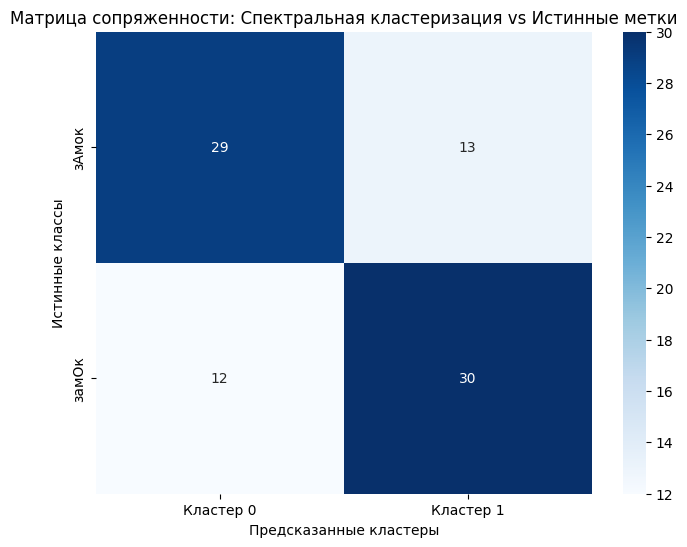


   Оптимальное сопоставление:
   Кластер 0 → зАмок (крепость)
   Кластер 1 → замОк (механизм)

   Accuracy (после сопоставления): 0.7024

   Отчет о классификации:
                  precision    recall  f1-score   support

зАмок (крепость)       0.71      0.69      0.70        42
замОк (механизм)       0.70      0.71      0.71        42

        accuracy                           0.70        84
       macro avg       0.70      0.70      0.70        84
    weighted avg       0.70      0.70      0.70        84


2. СРАВНЕНИЕ С ИСТИННЫМИ МЕТКАМИ:
   Adjusted Rand Index: 0.0105
Слабое соответствие


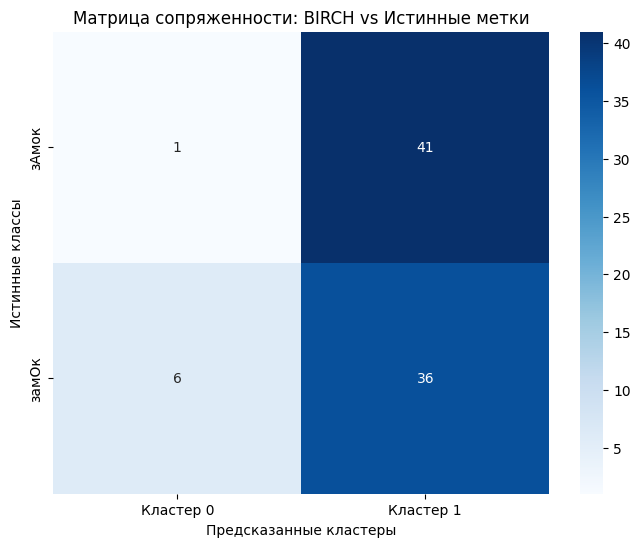


   Оптимальное сопоставление:
   Кластер 1 → зАмок (крепость)
   Кластер 0 → замОк (механизм)

   Accuracy (после сопоставления): 0.5595

   Отчет о классификации:
                  precision    recall  f1-score   support

зАмок (крепость)       0.53      0.98      0.69        42
замОк (механизм)       0.86      0.14      0.24        42

        accuracy                           0.56        84
       macro avg       0.69      0.56      0.47        84
    weighted avg       0.69      0.56      0.47        84

Встроенные
Случайный лес
Итерация   1: инерция = 280127.00, сдвиг центроидов = 37.663197

Сходимость достигнута на итерации 5

Обучение завершено. Финальная инерция: 158194.44
Распределение по кластерам:
  Кластер 0: 7 элементом (8.3%)
  Кластер 1: 77 элементом (91.7%)

2. СРАВНЕНИЕ С ИСТИННЫМИ МЕТКАМИ:
   Adjusted Rand Index: 0.0105
Слабое соответствие


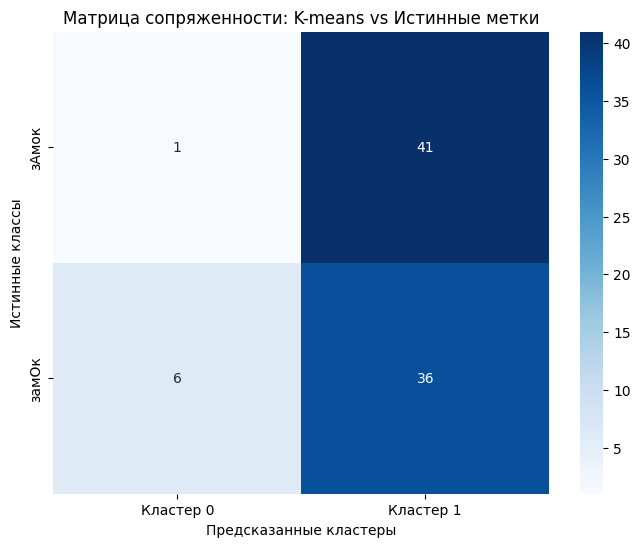


   Оптимальное сопоставление:
   Кластер 1 → зАмок (крепость)
   Кластер 0 → замОк (механизм)

   Accuracy (после сопоставления): 0.5595

   Отчет о классификации:
                  precision    recall  f1-score   support

зАмок (крепость)       0.53      0.98      0.69        42
замОк (механизм)       0.86      0.14      0.24        42

        accuracy                           0.56        84
       macro avg       0.69      0.56      0.47        84
    weighted avg       0.69      0.56      0.47        84


2. СРАВНЕНИЕ С ИСТИННЫМИ МЕТКАМИ:
   Adjusted Rand Index: 0.1536
Слабое соответствие


/home/mike-pech/Documents/masters-theory/ML/Practice/.venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


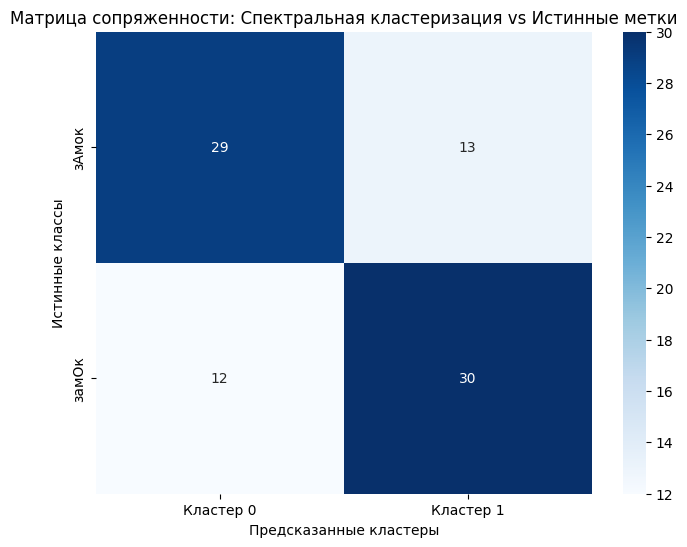


   Оптимальное сопоставление:
   Кластер 0 → зАмок (крепость)
   Кластер 1 → замОк (механизм)

   Accuracy (после сопоставления): 0.7024

   Отчет о классификации:
                  precision    recall  f1-score   support

зАмок (крепость)       0.71      0.69      0.70        42
замОк (механизм)       0.70      0.71      0.71        42

        accuracy                           0.70        84
       macro avg       0.70      0.70      0.70        84
    weighted avg       0.70      0.70      0.70        84


2. СРАВНЕНИЕ С ИСТИННЫМИ МЕТКАМИ:
   Adjusted Rand Index: 0.0105
Слабое соответствие


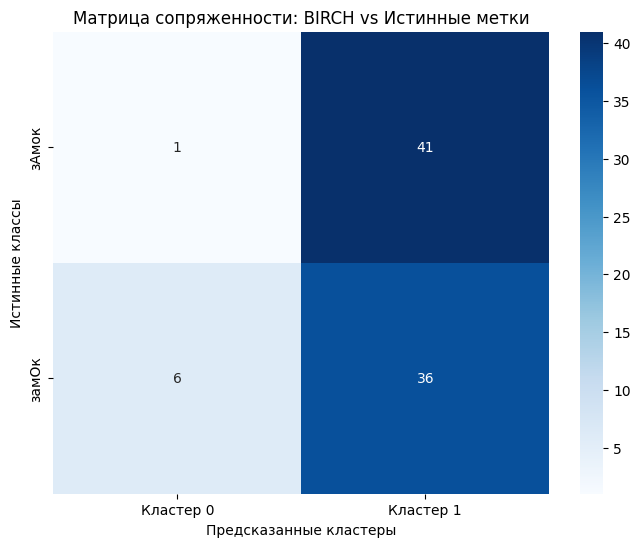


   Оптимальное сопоставление:
   Кластер 1 → зАмок (крепость)
   Кластер 0 → замОк (механизм)

   Accuracy (после сопоставления): 0.5595

   Отчет о классификации:
                  precision    recall  f1-score   support

зАмок (крепость)       0.53      0.98      0.69        42
замОк (механизм)       0.86      0.14      0.24        42

        accuracy                           0.56        84
       macro avg       0.69      0.56      0.47        84
    weighted avg       0.69      0.56      0.47        84

Обёртки
RFE
Итерация   1: инерция = 280127.00, сдвиг центроидов = 37.663197

Сходимость достигнута на итерации 5

Обучение завершено. Финальная инерция: 158194.44
Распределение по кластерам:
  Кластер 0: 7 элементом (8.3%)
  Кластер 1: 77 элементом (91.7%)

2. СРАВНЕНИЕ С ИСТИННЫМИ МЕТКАМИ:
   Adjusted Rand Index: 0.0105
Слабое соответствие


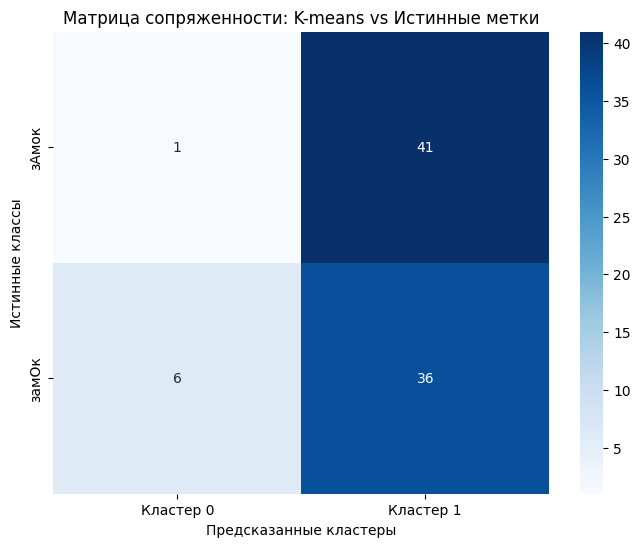


   Оптимальное сопоставление:
   Кластер 1 → зАмок (крепость)
   Кластер 0 → замОк (механизм)

   Accuracy (после сопоставления): 0.5595

   Отчет о классификации:
                  precision    recall  f1-score   support

зАмок (крепость)       0.53      0.98      0.69        42
замОк (механизм)       0.86      0.14      0.24        42

        accuracy                           0.56        84
       macro avg       0.69      0.56      0.47        84
    weighted avg       0.69      0.56      0.47        84


2. СРАВНЕНИЕ С ИСТИННЫМИ МЕТКАМИ:
   Adjusted Rand Index: 0.1536
Слабое соответствие


/home/mike-pech/Documents/masters-theory/ML/Practice/.venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


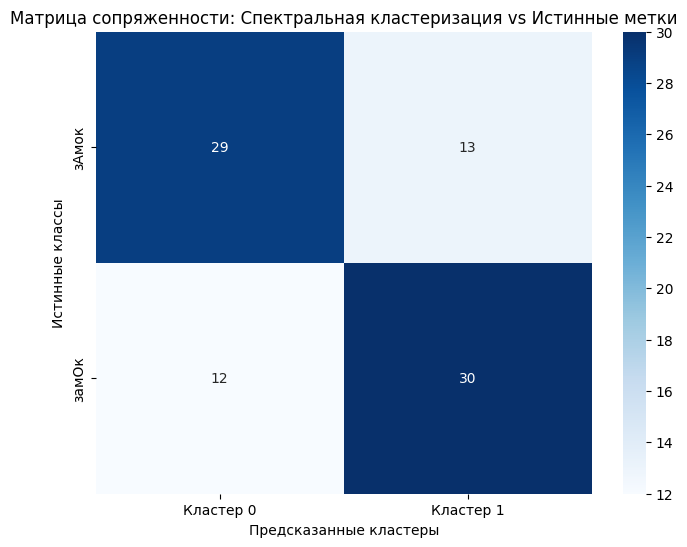


   Оптимальное сопоставление:
   Кластер 0 → зАмок (крепость)
   Кластер 1 → замОк (механизм)

   Accuracy (после сопоставления): 0.7024

   Отчет о классификации:
                  precision    recall  f1-score   support

зАмок (крепость)       0.71      0.69      0.70        42
замОк (механизм)       0.70      0.71      0.71        42

        accuracy                           0.70        84
       macro avg       0.70      0.70      0.70        84
    weighted avg       0.70      0.70      0.70        84


2. СРАВНЕНИЕ С ИСТИННЫМИ МЕТКАМИ:
   Adjusted Rand Index: 0.0105
Слабое соответствие


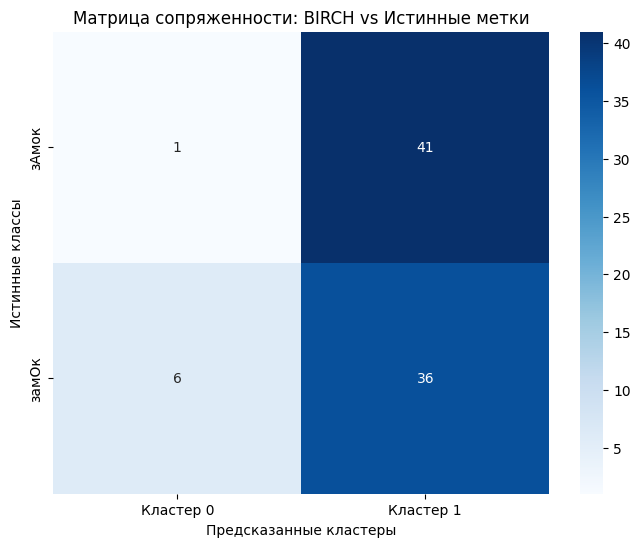


   Оптимальное сопоставление:
   Кластер 1 → зАмок (крепость)
   Кластер 0 → замОк (механизм)

   Accuracy (после сопоставления): 0.5595

   Отчет о классификации:
                  precision    recall  f1-score   support

зАмок (крепость)       0.53      0.98      0.69        42
замОк (механизм)       0.86      0.14      0.24        42

        accuracy                           0.56        84
       macro avg       0.69      0.56      0.47        84
    weighted avg       0.69      0.56      0.47        84



In [146]:
for method_type, submethods in feature_results.items():
    print(80*'=')
    print(method_type)
    for submethod, features in submethods.items():
        print(80*'=')
        print(submethod)
        if hasattr(X, 'toarray'):
            X_dense = X.toarray()[:, rf_indices]
        else:
            X_dense = X[:, rf_indices]

        kmeans = DIYKMeans(n_clusters=2, random_state=19)
        X_dense = X.toarray()
        kmeans.fit(X_dense)
        cluster_labels = kmeans.labels
        compare_with_true_labels(cluster_labels=cluster_labels, label="K-means")

        clustering = SpectralClustering(n_clusters=2,
            assign_labels='discretize',
            random_state=0).fit(X_dense)
        compare_with_true_labels(cluster_labels=clustering.labels_, label="Спектральная кластеризация")

        brc = Birch(n_clusters=2)
        brc.fit(X_dense)
        cluster_labels = brc.predict(X_dense)
        compare_with_true_labels(cluster_labels=cluster_labels, label="BIRCH")

# 3 — Уменьшение размерности

Методами PCA и tSNE уменьшим размерность данных до и после выбора признаков


Метод: mutual_info


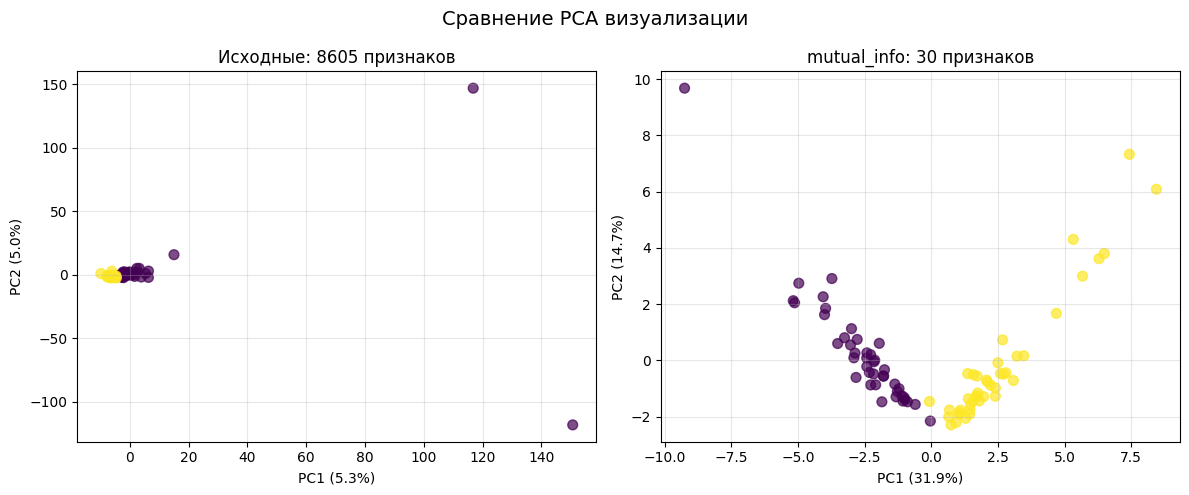

Исходные: объяснено 10.3% дисперсии
После mutual_info: объяснено 46.6% дисперсии

Метод: random_forest


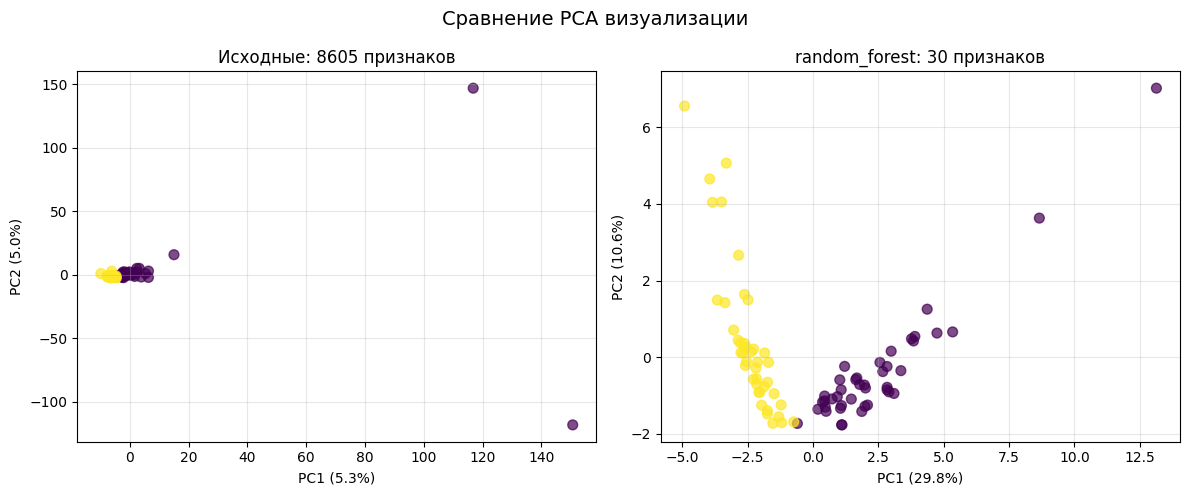

Исходные: объяснено 10.3% дисперсии
После random_forest: объяснено 40.4% дисперсии

Метод: chi2


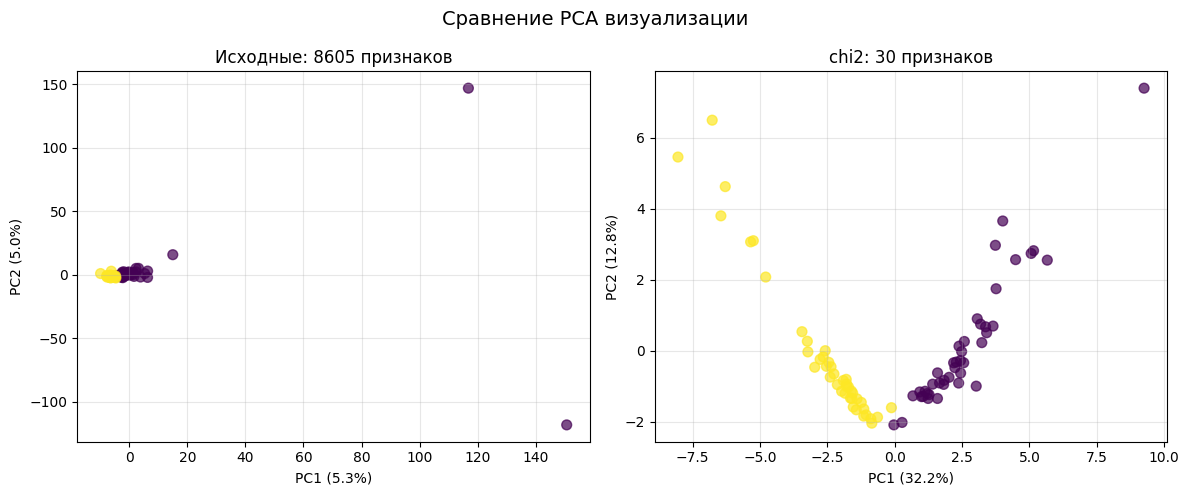

Исходные: объяснено 10.3% дисперсии
После chi2: объяснено 45.0% дисперсии

Метод: Lasso


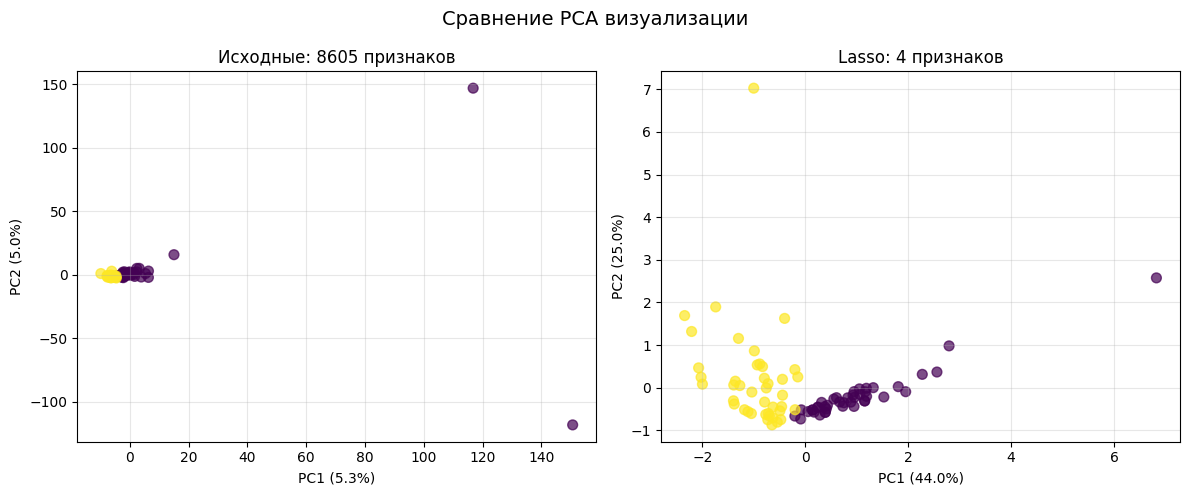

Исходные: объяснено 10.3% дисперсии
После Lasso: объяснено 69.1% дисперсии

Метод: RFE


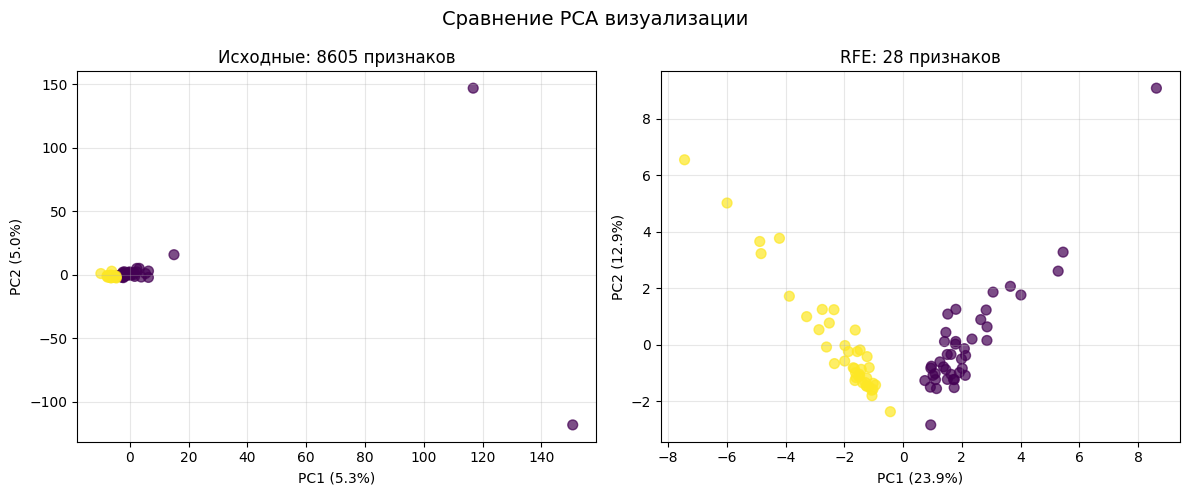

Исходные: объяснено 10.3% дисперсии
После RFE: объяснено 36.8% дисперсии


In [147]:
def plot_pca_comparison(X, y, selected_indices, method_name):
    # Преобразуем данные
    if hasattr(X, 'toarray'):
        X_dense = X.toarray()
    else:
        X_dense = X
    
    y = np.array(y)
    
    # Нормализация
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler(with_mean=False)
    X_full_norm = scaler.fit_transform(X_dense)
    X_selected_norm = scaler.transform(X_dense)[:, selected_indices]
    
    # PCA
    from sklearn.decomposition import PCA
    pca_full = PCA(n_components=2, random_state=42)
    X_pca_full = pca_full.fit_transform(X_full_norm)
    
    pca_selected = PCA(n_components=2, random_state=42)
    X_pca_selected = pca_selected.fit_transform(X_selected_norm)
    
    # График
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Исходные
    scatter1 = ax1.scatter(X_pca_full[:, 0], X_pca_full[:, 1], 
                          c=y, cmap='viridis', alpha=0.7, s=50)
    ax1.set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]:.1%})')
    ax1.set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]:.1%})')
    ax1.set_title(f'Исходные: {X_dense.shape[1]} признаков')
    ax1.grid(True, alpha=0.3)
    
    # После отбора
    scatter2 = ax2.scatter(X_pca_selected[:, 0], X_pca_selected[:, 1],
                          c=y, cmap='viridis', alpha=0.7, s=50)
    ax2.set_xlabel(f'PC1 ({pca_selected.explained_variance_ratio_[0]:.1%})')
    ax2.set_ylabel(f'PC2 ({pca_selected.explained_variance_ratio_[1]:.1%})')
    ax2.set_title(f'{method_name}: {len(selected_indices)} признаков')
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle(f'Сравнение PCA визуализации', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    print(f"Исходные: объяснено {pca_full.explained_variance_ratio_.sum():.1%} дисперсии")
    print(f"После {method_name}: объяснено {pca_selected.explained_variance_ratio_.sum():.1%} дисперсии")

for category in results:
    for method_name, method_data in results[category].items():
        if 'indices' in method_data:
            print(f"\nМетод: {method_name}")
            plot_pca_comparison(
                X=X,
                y=Y,
                selected_indices=method_data['indices'],
                method_name=method_name
            )